# EDA — Seguridad y Convivencia en Colombia (2018-2024)

Exploración inicial del modelo estrella en DuckDB.  
Fuente: Policía Nacional de Colombia — datos abiertos.

**Registros totales:** 3 308 736  
**Tipos de delito:** 18  
**Años:** 2018-2024  
**Departamentos:** 41

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')

REPO_ROOT = Path('..').resolve()
DB_PATH = REPO_ROOT / 'datos' / 'db' / 'seguridad_convivencia.duckdb'

# Verificar que la base de datos existe antes de conectar
if not DB_PATH.exists():
    raise FileNotFoundError(
        "❌ Base de datos DuckDB no encontrada.\n\n"
        "Primero ejecuta el pipeline ETL completo:\n\n"
        "  # 1. Ingesta de datos desde Policía Nacional\n"
        "  poetry run python -m src.ingesta.main\n\n"
        "  # 2. Transformación y creación del modelo estrella\n"
        "  poetry run python -m src.transformacion.main\n\n"
        f"\nArchivo esperado: {DB_PATH}"
    )

con = duckdb.connect(str(DB_PATH), read_only=True)

## 1. Resumen del modelo estrella

In [2]:
tablas = ['dim_fecha', 'dim_ubicacion', 'dim_delito', 'dim_arma', 'dim_victima', 'fact_delitos']
print(f"{'tabla':<25}{'filas':>10}")
for t in tablas:
    n = con.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0]
    print(f"{t:<25}{n:>10,}")

tabla                         filas
dim_fecha                         7
dim_ubicacion                 3,311
dim_delito                       18
dim_arma                         94
dim_victima                      19
fact_delitos              3,400,975


## 2. Evolución anual de delitos

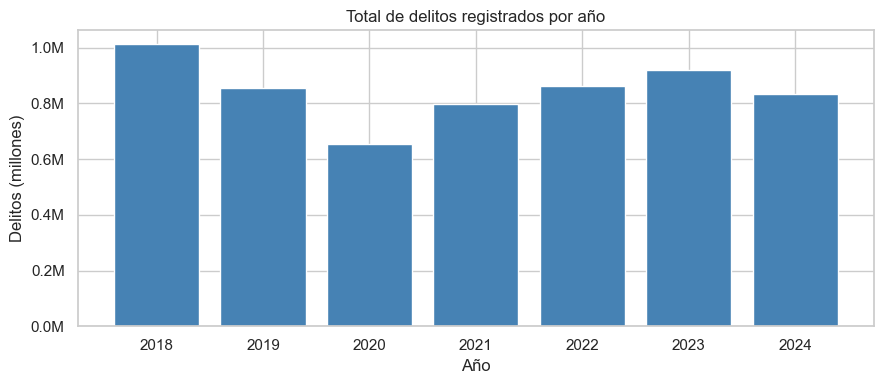

,anio,total
0,2018,1011103.0
1,2019,854922.0
2,2020,653072.0
3,2021,797472.0
4,2022,863672.0
5,2023,920010.0
6,2024,834172.0


In [3]:
df_anio = con.execute("""
    SELECT d.anio, SUM(f.cantidad) AS total
    FROM fact_delitos f
    JOIN dim_fecha d USING (fecha_key)
    GROUP BY 1 ORDER BY 1
""").df()

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(df_anio['anio'], df_anio['total'] / 1e6, color='steelblue')
ax.set_xlabel('Año')
ax.set_ylabel('Delitos (millones)')
ax.set_title('Total de delitos registrados por año')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))
plt.tight_layout()
plt.show()
df_anio

> **Nota:** 2020 muestra la caída más pronunciada, asociada a las restricciones de movilidad por COVID-19.

## 3. Top 10 departamentos con más delitos (2018-2024)

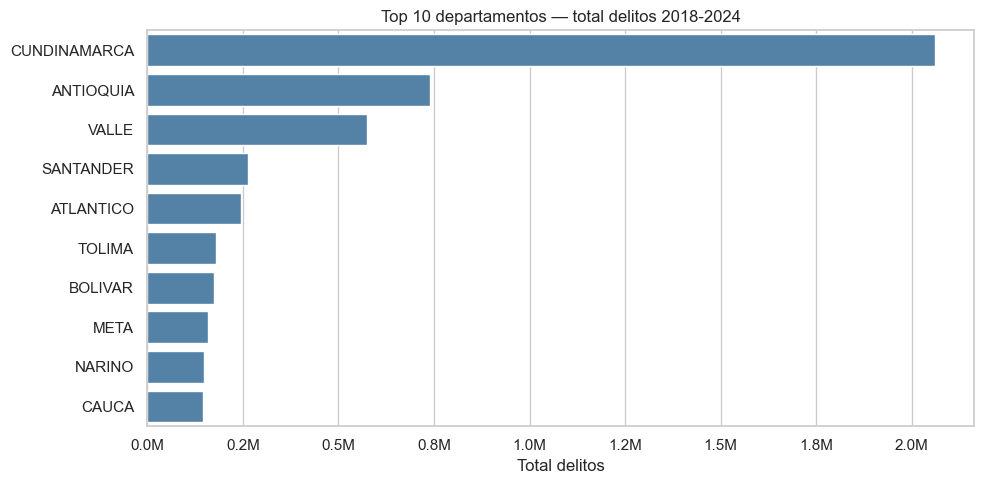

,departamento,total
0,CUNDINAMARCA,2060133.0
1,ANTIOQUIA,739906.0
2,VALLE,574365.0
3,SANTANDER,263928.0
4,ATLANTICO,245874.0
5,TOLIMA,179742.0
6,BOLIVAR,173985.0
7,META,157276.0
8,NARINO,147485.0
9,CAUCA,145021.0


In [4]:
df_depto = con.execute("""
    SELECT u.departamento, SUM(f.cantidad) AS total
    FROM fact_delitos f
    JOIN dim_ubicacion u USING (ubicacion_key)
    GROUP BY 1 ORDER BY 2 DESC
    LIMIT 10
""").df()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=df_depto, x='total', y='departamento', ax=ax, color='steelblue')
ax.set_xlabel('Total delitos')
ax.set_ylabel('')
ax.set_title('Top 10 departamentos — total delitos 2018-2024')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.show()
df_depto

## 4. Distribución por tipo de delito

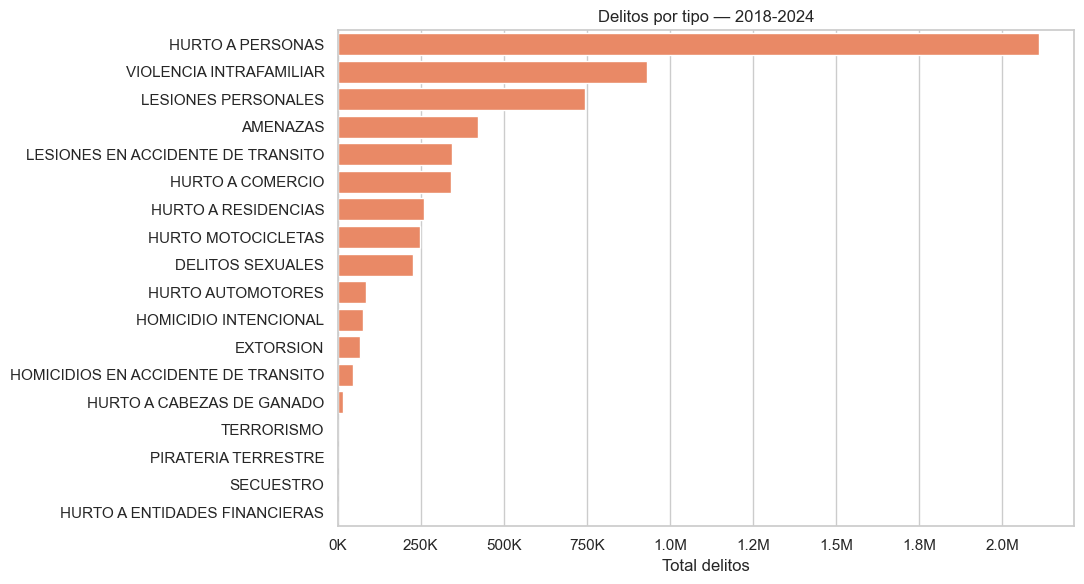

,tipo_delito,total
0,HURTO A PERSONAS,2110710.0
1,VIOLENCIA INTRAFAMILIAR,930647.0
2,LESIONES PERSONALES,745763.0
3,AMENAZAS,423304.0
4,LESIONES EN ACCIDENTE DE TRANSITO,344175.0
5,HURTO A COMERCIO,342458.0
6,HURTO A RESIDENCIAS,260558.0
7,HURTO MOTOCICLETAS,249468.0
8,DELITOS SEXUALES,227845.0
9,HURTO AUTOMOTORES,84250.0


In [5]:
df_delito = con.execute("""
    SELECT del.tipo_delito, SUM(f.cantidad) AS total
    FROM fact_delitos f
    JOIN dim_delito del USING (delito_key)
    GROUP BY 1 ORDER BY 2 DESC
""").df()

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=df_delito, x='total', y='tipo_delito', ax=ax, color='coral')
ax.set_xlabel('Total delitos')
ax.set_ylabel('')
ax.set_title('Delitos por tipo — 2018-2024')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{int(x/1e3)}K'))
plt.tight_layout()
plt.show()
df_delito

## 5. Mapa de calor: tipo de delito × año

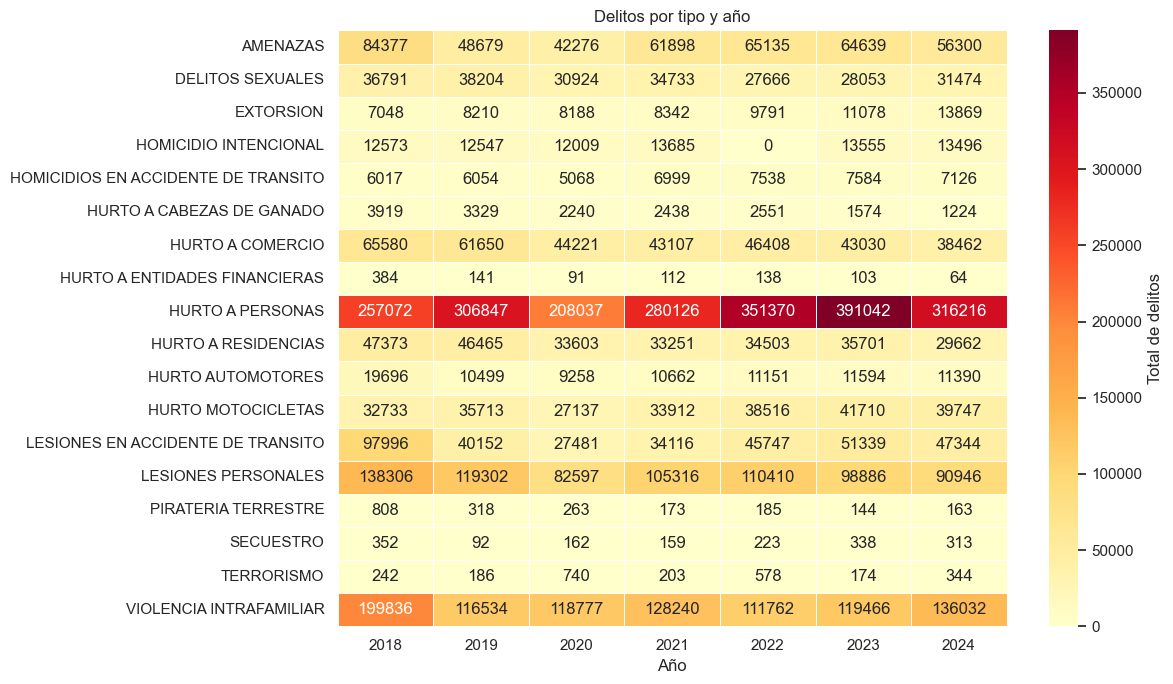

In [6]:
df_heat = con.execute("""
    SELECT d.anio, del.tipo_delito, SUM(f.cantidad) AS total
    FROM fact_delitos f
    JOIN dim_fecha  d   USING (fecha_key)
    JOIN dim_delito del USING (delito_key)
    GROUP BY 1, 2
""").df()

pivot = df_heat.pivot(index='tipo_delito', columns='anio', values='total').fillna(0)

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(
    pivot,
    annot=True, fmt='.0f', linewidths=0.5,
    cmap='YlOrRd', ax=ax,
    cbar_kws={'label': 'Total de delitos'}
)
ax.set_title('Delitos por tipo y año')
ax.set_xlabel('Año')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 6. Distribución por género

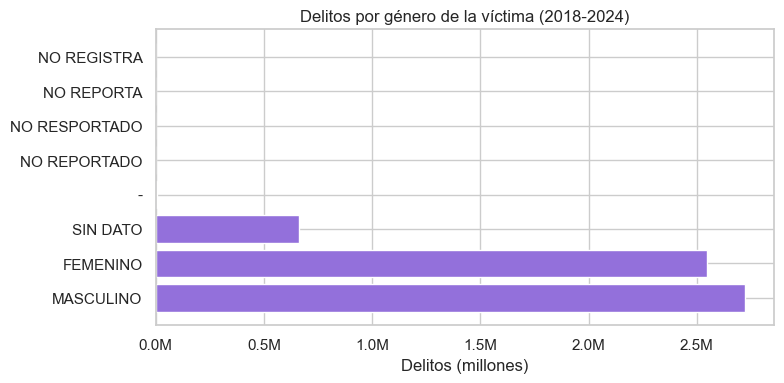

,genero,total
0,MASCULINO,2720142.0
1,FEMENINO,2544454.0
2,SIN DATO,662477.0
3,-,4327.0
4,NO REPORTADO,2233.0
5,NO RESPORTADO,375.0
6,NO REPORTA,370.0
7,NO REGISTRA,45.0


In [7]:
df_gen = con.execute("""
    SELECT v.genero, SUM(f.cantidad) AS total
    FROM fact_delitos f
    JOIN dim_victima v USING (victima_key)
    GROUP BY 1 ORDER BY 2 DESC
""").df()

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(df_gen['genero'], df_gen['total'] / 1e6, color='mediumpurple')
ax.set_xlabel('Delitos (millones)')
ax.set_title('Delitos por género de la víctima (2018-2024)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))
plt.tight_layout()
plt.show()
df_gen

## 7. Homicidios intencionales por departamento y año

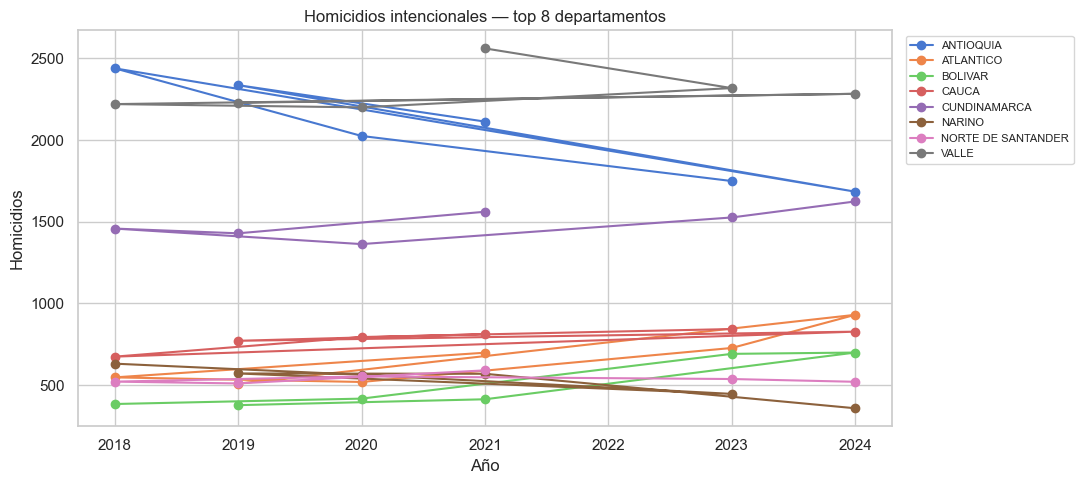

In [8]:
df_hom = con.execute("""
    SELECT d.anio, u.departamento, SUM(f.cantidad) AS total
    FROM fact_delitos f
    JOIN dim_fecha     d   USING (fecha_key)
    JOIN dim_ubicacion u   USING (ubicacion_key)
    JOIN dim_delito    del USING (delito_key)
    WHERE del.tipo_delito = 'HOMICIDIO INTENCIONAL'
    GROUP BY 1, 2
""").df()

# Top 8 departamentos
top8 = df_hom.groupby('departamento')['total'].sum().nlargest(8).index
df_plot = df_hom[df_hom['departamento'].isin(top8)]

fig, ax = plt.subplots(figsize=(11, 5))
for dept, grp in df_plot.groupby('departamento'):
    ax.plot(grp['anio'], grp['total'], marker='o', label=dept)
ax.set_xlabel('Año')
ax.set_ylabel('Homicidios')
ax.set_title('Homicidios intencionales — top 8 departamentos')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [9]:
con.close()
print('Conexion cerrada.')

Conexion cerrada.
